In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("data/processed/telco_clean.csv")


In [3]:
df.shape

(7043, 21)

In [4]:
print("Overall churn rate", round(df["Churn"].mean()*100,1))

Overall churn rate 26.5


In [6]:
contract_churn = df.groupby("Contract")["Churn"].mean()*100


In [8]:
contract_churn.round(2)

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

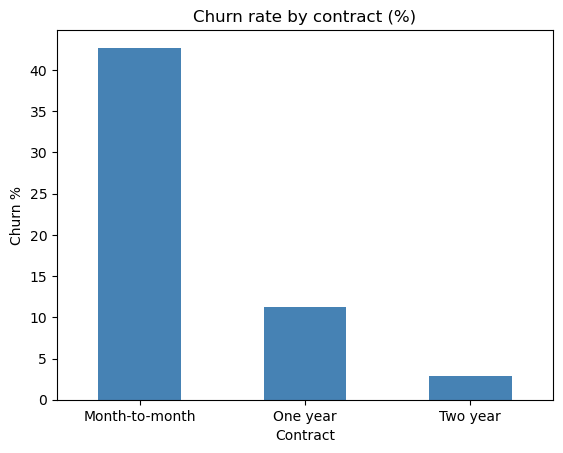

In [11]:
contract_churn.plot(kind = "bar", title="Churn rate by contract (%)", color = "steelblue")
plt.ylabel("Churn %")
plt.xticks(rotation = 0)
plt.show()

In [13]:
df["tenure_group"] = pd.cut(df["tenure"], bins = [-1,12,24,48,72], labels = ["0-12 months", "13-24","25-48","49-72"])

df.groupby("tenure_group", observed = True)["Churn"].mean().mul(100).round(1)

tenure_group
0-12 months    47.4
13-24          28.7
25-48          20.4
49-72           9.5
Name: Churn, dtype: float64

In [16]:
df.groupby("Churn")["MonthlyCharges"].mean().round(2)



Churn
0    61.27
1    74.44
Name: MonthlyCharges, dtype: float64

In [17]:
df.groupby("InternetService")["Churn"].mean().mul(100).round(2)

InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

In [19]:
for col in ["OnlineSecurity","TechSupport"]:
    print(df.groupby(col)["Churn"].mean().mul(100).round(2))

OnlineSecurity
0    31.33
1    14.61
Name: Churn, dtype: float64
TechSupport
0    31.19
1    15.17
Name: Churn, dtype: float64


In [21]:
df.groupby("PaymentMethod")["Churn"].mean().mul(100).round(2).sort_values(ascending = False)

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64

In [22]:
for col in ["gender", "SeniorCitizen", "Partner", "Dependents"]:
    print(df.groupby(col)["Churn"].mean().mul(100).round(2))
    

gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64
SeniorCitizen
0    23.61
1    41.68
Name: Churn, dtype: float64
Partner
0    32.96
1    19.66
Name: Churn, dtype: float64
Dependents
0    31.28
1    15.45
Name: Churn, dtype: float64


Text(0.5, 0, 'Churn %')

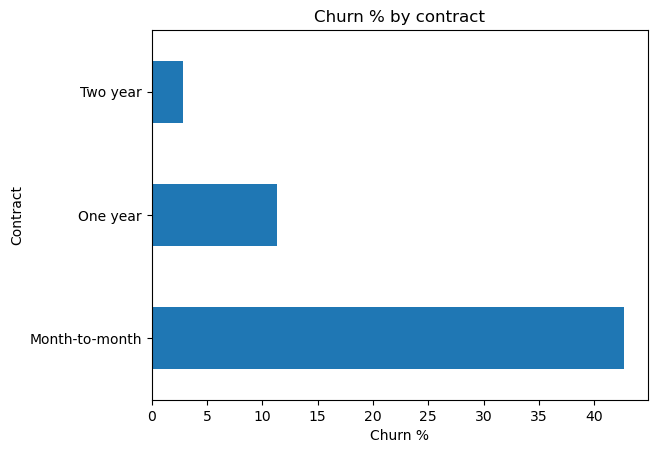

In [25]:
df.groupby("Contract")["Churn"]. mean().mul(100).round(1).plot(kind = "barh", title = "Churn % by contract")
plt.xlabel("Churn %")


In [27]:
eda_summary = """
Customer with long year plan are less likely to be churned
Customer have high churned chances in first year, so initial service and support is very much needed.
Churned chustomer pay 13 dollar more. This may push people out
Customer which do not have tech support still churned about 31.19 %
Electronic check have high churned rate, may be it provide feature to cancel it any time and more easy steps, or it is just an outlier
senior and people without partner or dependents leave more irrespective of their gender

Month to month contract churn most,than one year and two year are the least churned. In simple, offering longer contracts could keep at risk customer.

"""
with open("C:/Users/slmkc/Downloads/PhaseI/Churn_model/reports/eda_summary.md","w") as f:
    f.write(eda_summary)
    

